# 04 — Classifier Explainability (SHAP)

Every prediction must surface the top contributing features.
Counselors see WHY — never just a score.

Plan §Output Design: 'Three contributing factors shown via SHAP — counselor sees what behavioral pattern drove the score.'

In [1]:
import sys
from pathlib import Path

repo_root = Path(".").resolve().parent
sys.path.insert(0, str(repo_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from src.risk_classifier import FEATURE_COLS, TARGET_COL, load_model, predict_score

df = pd.read_csv(repo_root / "data" / "synthetic" / "student_wellbeing.csv")
bundle = load_model()
print(f"Loaded {bundle.model_name} model trained at {bundle.trained_at}")

Loaded xgboost model trained at 2026-04-26T02:58:42.701240+00:00


## 1. Global SHAP Summary (Feature Importance)

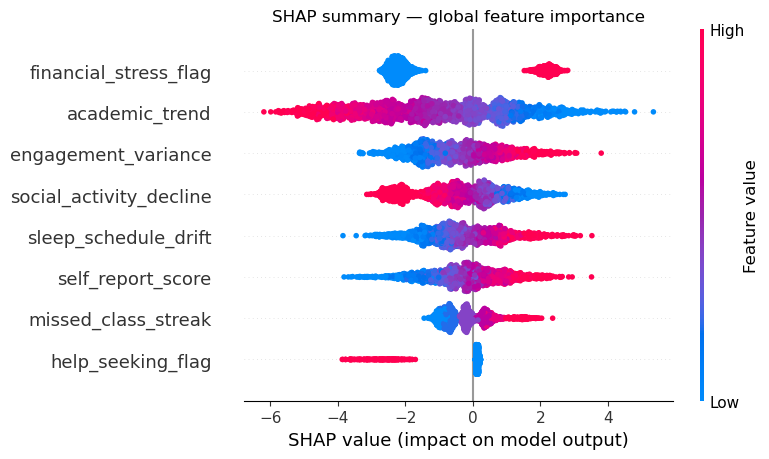

In [2]:
# Use a sample for SHAP (full 30k is slow for plots)
sample = df[FEATURE_COLS].sample(2000, random_state=42)
X_sample = sample.values

pipeline = bundle.raw_pipeline
scaler = pipeline.named_steps["scaler"]
clf = pipeline.named_steps["clf"]
X_scaled = scaler.transform(X_sample)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_scaled)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # RandomForest returns list; XGB returns array

plt.figure()
shap.summary_plot(shap_values, X_scaled, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP summary — global feature importance")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. SHAP Bar Plot (Mean Absolute SHAP)

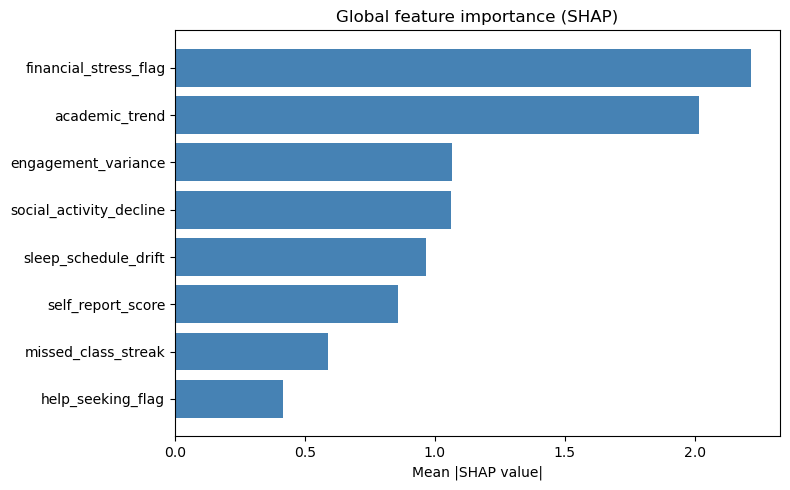

                feature  mean_abs_shap
  financial_stress_flag       2.216829
         academic_trend       2.014510
    engagement_variance       1.067298
social_activity_decline       1.063008
   sleep_schedule_drift       0.967336
      self_report_score       0.859534
    missed_class_streak       0.589316
      help_seeking_flag       0.416314


In [3]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
shap_df = shap_df.sort_values("mean_abs_shap", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(shap_df["feature"], shap_df["mean_abs_shap"], color="steelblue")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Global feature importance (SHAP)")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "shap_bar.png", dpi=120, bbox_inches="tight")
plt.show()
print(shap_df.sort_values("mean_abs_shap", ascending=False).to_string(index=False))

## 3. Per-Prediction SHAP Waterfall (High-Score Example)

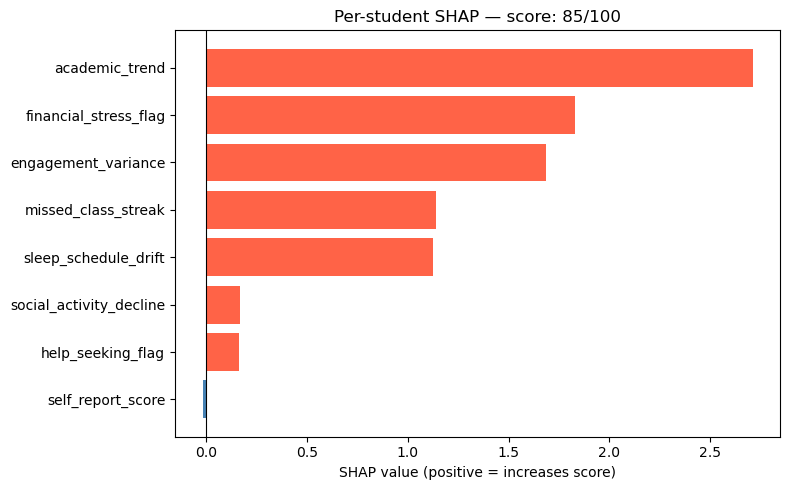


Counselor-facing output:
Support recommendation score: 85/100 - Outreach recommended | Top contributing signals: Academic performance trend (+), Financial stress indicator (+), LMS engagement variability (+)


In [4]:
# Find a high-scoring student to illustrate counselor output
all_probs = bundle.calibrated_pipeline.predict_proba(df[FEATURE_COLS].values)[:, 1]
high_idx = np.argsort(all_probs)[-1]  # highest probability student

X_one = df[FEATURE_COLS].iloc[[high_idx]].values
X_one_scaled = scaler.transform(X_one)

sv_one = explainer.shap_values(X_one_scaled)
if isinstance(sv_one, list):
    sv_one = sv_one[1]

fig, ax = plt.subplots(figsize=(8, 5))
sv_single = sv_one[0]
sorted_idx = np.argsort(np.abs(sv_single))[::-1]
features_sorted = [FEATURE_COLS[i] for i in sorted_idx]
values_sorted = sv_single[sorted_idx]
colors = ["tomato" if v > 0 else "steelblue" for v in values_sorted]
ax.barh(features_sorted[::-1], values_sorted[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value (positive = increases score)")
ax.set_title(f"Per-student SHAP — score: {all_probs[high_idx]*100:.0f}/100")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "shap_waterfall_example.png", dpi=120, bbox_inches="tight")
plt.show()

# Counselor-facing output
result = predict_score(bundle, df[FEATURE_COLS].iloc[[high_idx]], compute_shap=True)[0]
print("\nCounselor-facing output:")
print(result.display_text)

## 4. SHAP Dependence Plots (Top 3 Features)

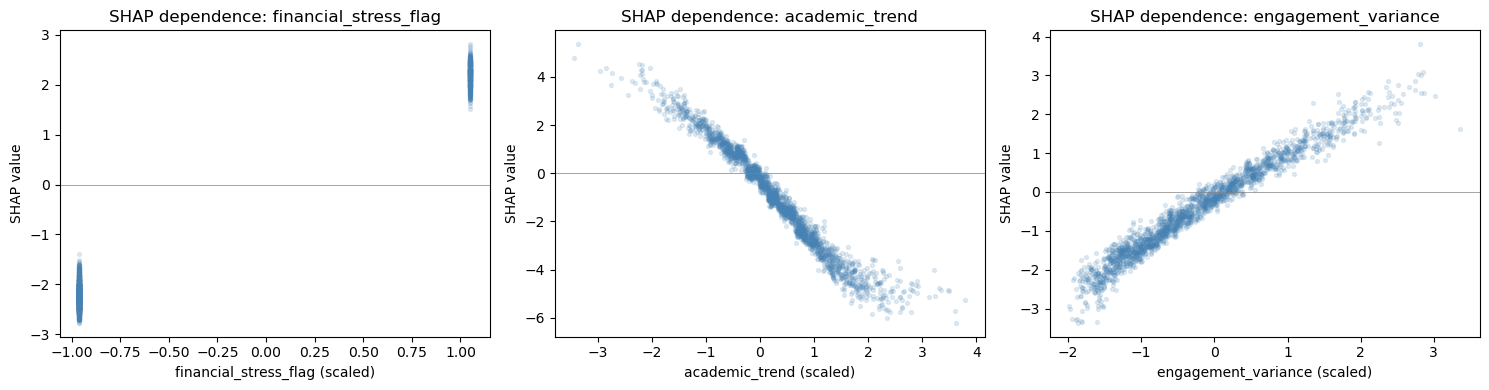

In [5]:
top3_features = shap_df.sort_values("mean_abs_shap", ascending=False)["feature"].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(top3_features):
    feat_idx = FEATURE_COLS.index(feat)
    axes[i].scatter(X_scaled[:, feat_idx], shap_values[:, feat_idx], alpha=0.15, s=8, color="steelblue")
    axes[i].axhline(0, color="gray", linewidth=0.5)
    axes[i].set_xlabel(f"{feat} (scaled)")
    axes[i].set_ylabel("SHAP value")
    axes[i].set_title(f"SHAP dependence: {feat}")

plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "shap_dependence_top3.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Cultural Normality Check

Manual review flag from the plan: check whether any feature contribution pattern
may reflect cultural difference rather than distress. Particularly:
- Quiet engagement style vs. withdrawal
- Lower social event participation (not a distress signal for all students)

In [6]:
# SHAP values for social_activity_decline by race/ethnicity
social_idx = FEATURE_COLS.index("social_activity_decline")
social_shap = shap_values[:, social_idx]
engagement_idx = FEATURE_COLS.index("engagement_variance")
engagement_shap = shap_values[:, engagement_idx]

sample_demo = df.iloc[sample.index.tolist()]

print("Mean SHAP value for social_activity_decline by race/ethnicity:")
for group in sample_demo["race_ethnicity"].unique():
    mask = sample_demo["race_ethnicity"] == group
    mean_sv = social_shap[mask.values].mean()
    print(f"  {group}: {mean_sv:.4f}")

print("\nMean SHAP value for engagement_variance by first_gen:")
for group in [0, 1]:
    label = "continuing-gen" if group == 0 else "first-gen"
    mask = sample_demo["first_gen"] == group
    mean_sv = engagement_shap[mask.values].mean()
    print(f"  {label}: {mean_sv:.4f}")

print("\n⚠️  Cultural normality notes for reviewer:")
print("  - social_activity_decline SHAP should be reviewed for any group where")
print("    lower participation is culturally normal, not distress-linked.")
print("  - If SHAP magnitudes differ significantly across groups, flag for Phase 5 bias audit.")

Mean SHAP value for social_activity_decline by race/ethnicity:
  asian: -0.3226
  black: -0.5224
  white: -0.3802
  multiracial: -0.2941
  hispanic_latino: -0.4323
  other: -0.8717
  prefer_not_to_say: -0.6273
  native_american: 0.0673
  pacific_islander: -0.8535

Mean SHAP value for engagement_variance by first_gen:
  continuing-gen: -0.4568
  first-gen: -0.4107

⚠️  Cultural normality notes for reviewer:
  - social_activity_decline SHAP should be reviewed for any group where
    lower participation is culturally normal, not distress-linked.
  - If SHAP magnitudes differ significantly across groups, flag for Phase 5 bias audit.
